# LISA glitch inference — TDI 1 vs TDI 2

Single shapelet glitch in stationary LISA noise. Key checks:
- SNRs are equal in TDI-1 and TDI-2 (with correct PSD for each)
- Empirical noise spectrum matches the analytical PSD
- Both posteriors recover the same parameters

**Parameterization:** sample `[τ, log A, log β]` where `A = Δv·β` (amplitude) and `β` (shape).
The product `A = Δv·β` is well-constrained by the data (`σ(logA) ~ 0.02`), whereas `Δv` and `β` individually are ~99% anti-correlated and barely separable.


In [13]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import jax.random as jr
import jax.lax as lax
import numpy as np
import matplotlib.pyplot as plt

import jaxglitches as jg
import noise as ns
from jaxglitches.priors import _DELTAV_MIN, _DELTAV_MAX, _BETA_MIN, _BETA_MAX

print('JAX devices:', jax.devices())


JAX devices: [CpuDevice(id=0)]


## 1. Setup and true parameters

In [14]:
T_OBS = jg.T_OBS_s
DT    = jg.DT_s
T_ARM = jg.T_ARM_s

freq   = jg.freq_grid(T_OBS, DT)
f_safe = jnp.where(freq > 0, freq, 1.0)

# TDI-1 and TDI-2 have DIFFERENT noise PSDs: S_TDI2 = 4 sin^2(4pi f T) * S_TDI1
psd1 = ns.psd_tdi1_array(f_safe)
psd2 = ns.psd_tdi2_array(f_safe)

TAU_TRUE    = 400.0
DELTAV_TRUE = 1.2e-13
BETA_TRUE   = 0.79
A_TRUE      = DELTAV_TRUE * BETA_TRUE   # = 9.48e-14  (well-constrained amplitude)
params_true = jnp.array([TAU_TRUE, DELTAV_TRUE, BETA_TRUE])

h1 = jg.clean_signal(params_true, freq, T=T_ARM, tdi=1)
h2 = jg.clean_signal(params_true, freq, T=T_ARM, tdi=2)
snr1 = jg.snr(h1, psd1)
snr2 = jg.snr(h2, psd2)
print(f'SNR  TDI-1: {snr1:.3f}')
print(f'SNR  TDI-2: {snr2:.3f}')
print(f'SNR ratio   (must be 1): {snr2/snr1:.6f}')
print(f'A_true = Dv * beta = {A_TRUE:.3e} m')


SNR  TDI-1: 49.891
SNR  TDI-2: 49.891
SNR ratio   (must be 1): 1.000000
A_true = Dv * beta = 9.480e-14 m


In [15]:
key = jr.PRNGKey(0)
kn1, kn2, kmc = jr.split(key, 3)

n1_fd = ns.sample_noise_fd(kn1, psd1)
n2_fd = ns.sample_noise_fd(kn2, psd2)
data1 = h1 + n1_fd
data2 = h2 + n2_fd

print(f'(d|h)/SNR^2  TDI-1: {jg.inner_product(data1, h1, psd1)/snr1**2:.3f}  (exp. ~1)')
print(f'(d|h)/SNR^2  TDI-2: {jg.inner_product(data2, h2, psd2)/snr2**2:.3f}  (exp. ~1)')


(d|h)/SNR^2  TDI-1: 1.000  (exp. ~1)
(d|h)/SNR^2  TDI-2: 1.032  (exp. ~1)


## 2. Signal and noise in the frequency domain

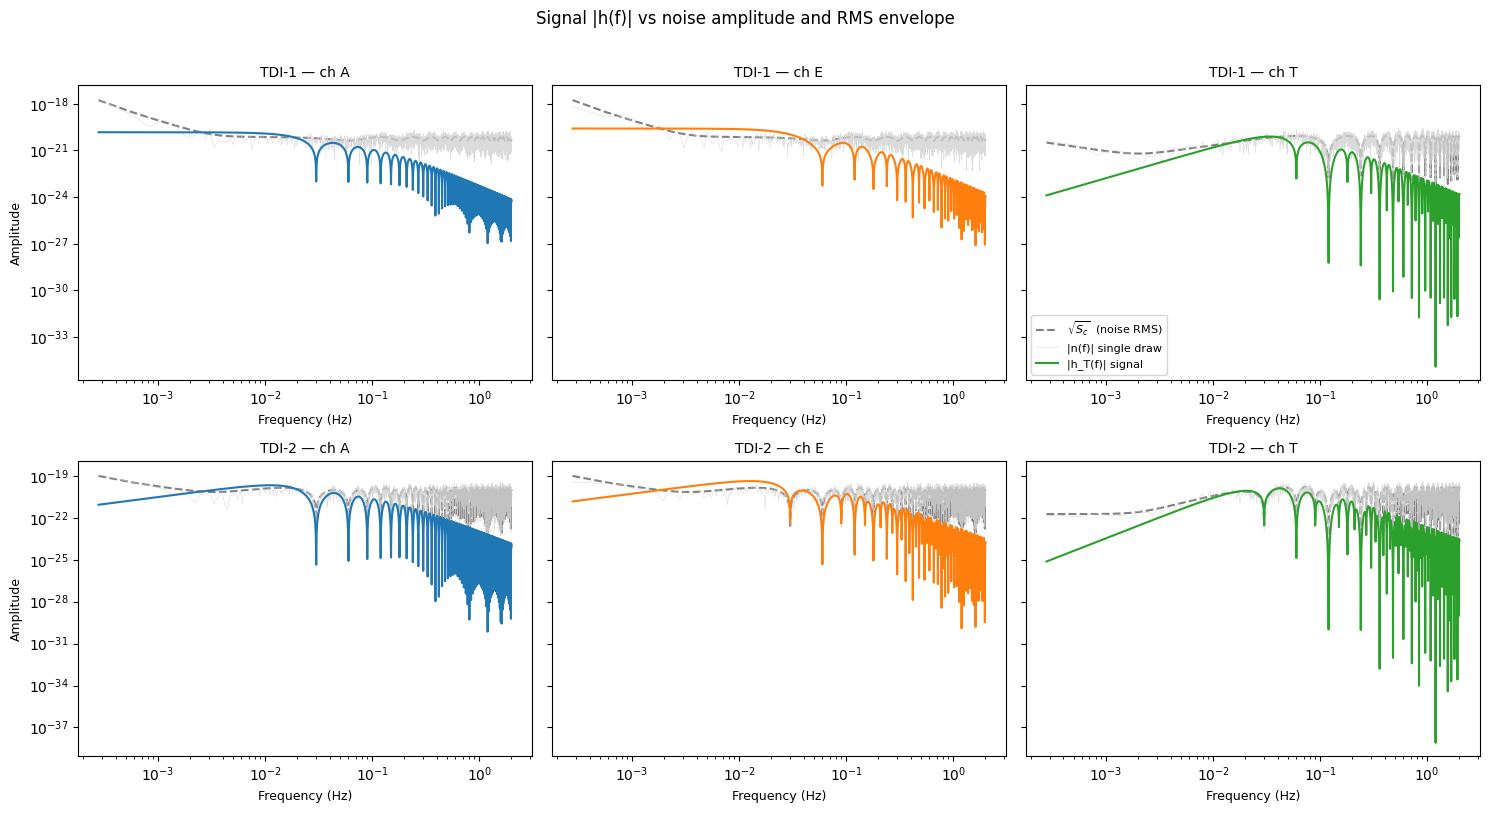

In [16]:
f_plot = np.array(freq[1:])
ch_labels = ['A', 'E', 'T']
ch_colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey='row')

for col, (ch, clr) in enumerate(zip(ch_labels, ch_colors)):
    for row, (h_fd, n_fd, psd, lbl) in enumerate([
            (h1, n1_fd, psd1, 'TDI-1'),
            (h2, n2_fd, psd2, 'TDI-2')]):
        ax = axes[row, col]
        ax.loglog(f_plot, np.sqrt(np.array(psd[1:,col])), 'gray', lw=1.5, ls='--',
                  label=r'$\sqrt{S_c}$  (noise RMS)', zorder=1)
        ax.loglog(f_plot, np.abs(np.array(n_fd[1:,col])), color='lightgray', lw=0.4,
                  alpha=0.8, label='|n(f)| single draw', zorder=2)
        ax.loglog(f_plot, np.abs(np.array(h_fd[1:,col])), color=clr, lw=1.5,
                  label=f'|h_{ch}(f)| signal', zorder=3)
        ax.set_title(f'{lbl} — ch {ch}', fontsize=10)
        ax.set_xlabel('Frequency (Hz)', fontsize=9)
        if col == 0: ax.set_ylabel('Amplitude', fontsize=9)
        if row == 0 and col == 2: ax.legend(fontsize=8, loc='lower left')

plt.suptitle('Signal |h(f)| vs noise amplitude and RMS envelope', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 3. PSD validation — analytical vs empirical periodogram

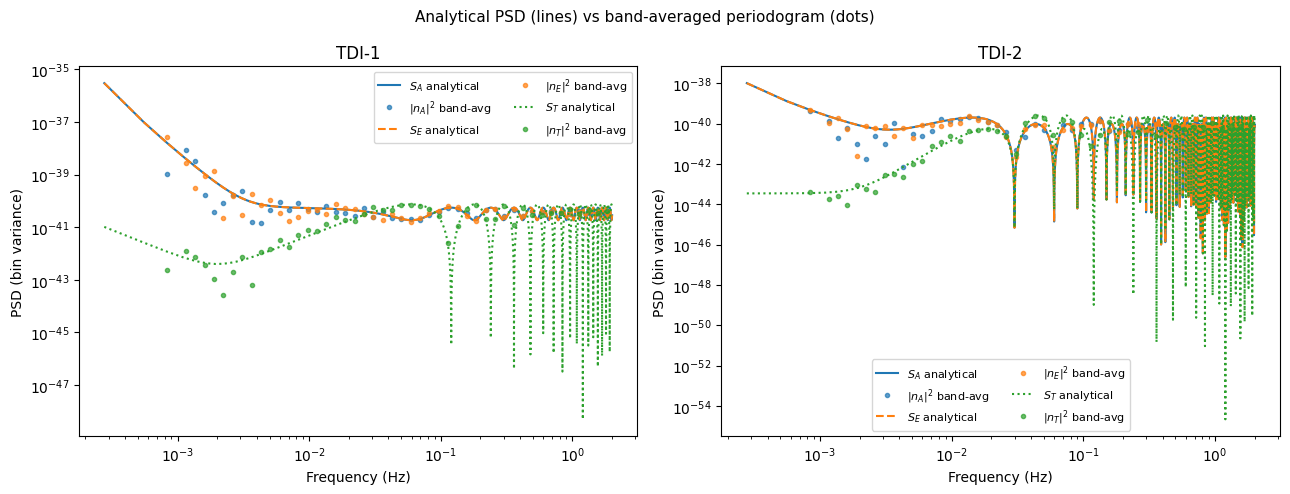

In [17]:
def band_avg(f, power_sq, n_bins=50):
    edges = np.logspace(np.log10(f[1]), np.log10(f[-1]), n_bins + 1)
    fc    = np.sqrt(edges[:-1] * edges[1:])
    avg   = np.zeros((n_bins, power_sq.shape[1]))
    for i in range(n_bins):
        mask = (f >= edges[i]) & (f < edges[i+1])
        if mask.sum() > 0:
            avg[i] = np.mean(power_sq[mask], axis=0)
    return fc, avg

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, n_fd, psd, title in zip(axes, [n1_fd, n2_fd], [psd1, psd2], ['TDI-1', 'TDI-2']):
    nf_sq = np.abs(np.array(n_fd[1:]))**2
    fc, avg = band_avg(f_plot, nf_sq)
    for ci, (ch, ls) in enumerate(zip(ch_labels, ['-','--',':'])):
        clr = ch_colors[ci]
        ax.loglog(f_plot, np.array(psd[1:,ci]), color=clr, lw=1.5, ls=ls,
                  label=f'$S_{ch}$ analytical')
        ax.loglog(fc, avg[:,ci], 'o', color=clr, ms=3, alpha=0.7,
                  label=f'$|n_{ch}|^2$ band-avg')
    ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('PSD (bin variance)')
    ax.set_title(title); ax.legend(fontsize=8, ncol=2)
plt.suptitle('Analytical PSD (lines) vs band-averaged periodogram (dots)', fontsize=11)
plt.tight_layout()
plt.show()


## 4. Sampling parameterization

We sample in `[τ,  log A,  log β]` where `A = Δv·β` is the glitch amplitude.  
In the original `[Δv, β]` parameterization these two are 99% anti-correlated — only `A = Δv·β` is data-constrained.  
In `[A, β]` the correlation drops to ~0.25 and `σ(log A) ≈ 0.02` vs `σ(log β) ≈ 0.12`.


In [18]:
# Prior bounds for A = Deltav * beta
A_MIN = _DELTAV_MIN * _BETA_MIN
A_MAX = _DELTAV_MAX * _BETA_MAX
LOG_A_MIN,    LOG_A_MAX    = jnp.log(A_MIN),    jnp.log(A_MAX)
LOG_BETA_MIN, LOG_BETA_MAX = jnp.log(_BETA_MIN), jnp.log(_BETA_MAX)

def to_physical_AB(xi):
    """[tau, logA, logBeta] -> [tau, Deltav, beta]"""
    tau, logA, logBeta = xi[0], xi[1], xi[2]
    beta   = jnp.exp(logBeta)
    Deltav = jnp.exp(logA) / beta
    return jnp.array([tau, Deltav, beta])

xi_true_AB = jnp.array([TAU_TRUE, jnp.log(A_TRUE), jnp.log(BETA_TRUE)])

def log_prior_AB(xi):
    tau, logA, logBeta = xi[0], xi[1], xi[2]
    logDv = logA - logBeta
    ok = ((tau    >= 0.)           & (tau    <= T_OBS)
        & (logA   >= LOG_A_MIN)    & (logA   <= LOG_A_MAX)
        & (logBeta >= LOG_BETA_MIN) & (logBeta <= LOG_BETA_MAX)
        & (logDv  >= jnp.log(_DELTAV_MIN)) & (logDv <= jnp.log(_DELTAV_MAX)))
    return jnp.where(ok, 0., -jnp.inf)

log_L1 = jg.make_log_likelihood(data1, psd1, freq, T=T_ARM, tdi=1)
log_L2 = jg.make_log_likelihood(data2, psd2, freq, T=T_ARM, tdi=2)

@jax.jit
def lp1(xi): return log_L1(to_physical_AB(xi)) + log_prior_AB(xi)
@jax.jit
def lp2(xi): return log_L2(to_physical_AB(xi)) + log_prior_AB(xi)

# --- MAP via L-BFGS-B ---
# The noise realization shifts the posterior peak away from truth.
# Computing the Hessian (for MALA whitening) at the MAP rather than at truth
# gives the correct proposal covariance and ensures a good acceptance rate.
from scipy.optimize import minimize as scipy_minimize

def find_map(lp_fn, xi_init):
    grad_lp = jax.jit(jax.grad(lp_fn))
    res = scipy_minimize(
        lambda x: -float(lp_fn(jnp.array(x))),
        np.array(xi_init),
        jac=lambda x: -np.array(grad_lp(jnp.array(x))),
        method='L-BFGS-B',
        options={'maxiter': 2000, 'ftol': 1e-15, 'gtol': 1e-8}
    )
    return jnp.array(res.x)

xi_map1 = find_map(lp1, xi_true_AB)
xi_map2 = find_map(lp2, xi_true_AB)

print(f'{"":12s}  {"tau":>10s}  {"logA":>10s}  {"logBeta":>10s}')
print(f'{"Truth":12s}  {float(xi_true_AB[0]):10.4f}  {float(xi_true_AB[1]):10.4f}  {float(xi_true_AB[2]):10.4f}')
print(f'{"MAP TDI-1":12s}  {float(xi_map1[0]):10.4f}  {float(xi_map1[1]):10.4f}  {float(xi_map1[2]):10.4f}')
print(f'{"MAP TDI-2":12s}  {float(xi_map2[0]):10.4f}  {float(xi_map2[1]):10.4f}  {float(xi_map2[2]):10.4f}')

# Hessian at MAP → correct whitening for MALA
H1 = jax.hessian(lp1)(xi_map1);  C1 = -jnp.linalg.inv(H1)
H2 = jax.hessian(lp2)(xi_map2);  C2 = -jnp.linalg.inv(H2)
sigma1 = jnp.sqrt(jnp.diag(C1));  sigma2 = jnp.sqrt(jnp.diag(C2))
corr1  = np.array(C1 / jnp.outer(sigma1, sigma1))
corr2  = np.array(C2 / jnp.outer(sigma2, sigma2))

print('\nLaplace sigmas at MAP  [tau,    logA,   logBeta]')
print(f'  TDI-1: {np.array(sigma1)}')
print(f'  TDI-2: {np.array(sigma2)}')
print(f'  rho(logA, logBeta) TDI-1: {corr1[1,2]:.3f}')
print(f'  rho(logA, logBeta) TDI-2: {corr2[1,2]:.3f}')


                     tau        logA     logBeta
Truth           400.0000    -29.9870     -0.2357
MAP TDI-1       399.9948    -29.9882     -0.2708
MAP TDI-2       399.9332    -29.9494     -0.1066

Laplace sigmas at MAP  [tau,    logA,   logBeta]
  TDI-1: [0.17440925 0.02074053 0.129813  ]
  TDI-2: [0.20609252 0.02044065 0.12949959]
  rho(logA, logBeta) TDI-1: 0.258
  rho(logA, logBeta) TDI-2: 0.312


## 5. Whitened MALA sampler

MALA (Metropolis-Adjusted Langevin) with EPS ≈ 1.5 in whitened coordinates.  
At this step size the acceptance rate is ~55%, close to the optimal 57% for 3-D.


In [19]:
EPS = 1.5

def make_mala(lp_fn, Lc):
    Li = jnp.linalg.inv(Lc)
    def lpw(xw): return lp_fn(Lc @ xw)
    gw = jax.jit(jax.grad(lpw))

    @jax.jit
    def _step(carry, key):
        xw, lp, g = carry
        kn, ku = jr.split(key)
        dr   = 0.5 * EPS**2 * g
        xwp  = xw + dr + EPS * jr.normal(kn, (3,))
        lpp  = lpw(xwp);   gp = gw(xwp)
        drb  = 0.5 * EPS**2 * gp
        lqf  = -0.5/EPS**2 * jnp.sum((xwp - xw - dr)**2)
        lqb  = -0.5/EPS**2 * jnp.sum((xw - xwp - drb)**2)
        acc  = jnp.log(jr.uniform(ku)) < lpp - lp + lqb - lqf
        xw_n = jnp.where(acc, xwp, xw)
        lp_n = jnp.where(acc, lpp, lp)
        g_n  = jnp.where(acc, gp, g)
        return (xw_n, lp_n, g_n), (xw_n, acc)

    def run(key, xi0, n):
        xw0 = Li @ xi0
        _, (cw, ac) = lax.scan(_step, (xw0, lpw(xw0), gw(xw0)), jr.split(key, n))
        return jax.vmap(lambda xw: Lc @ xw)(cw), ac.mean()

    return run


L1c = jnp.linalg.cholesky(C1)
L2c = jnp.linalg.cholesky(C2)

mala1 = make_mala(lp1, L1c)
mala2 = make_mala(lp2, L2c)

N_BURN = 500
N_SAMP = 20_000
k_b1, k_b2, k_s1, k_s2 = jr.split(kmc, 4)

# Warm-up from MAP (not truth): the noise realization shifts the peak,
# so starting from the MAP avoids a transient burn-in phase.
chain_b1, ar_b1 = mala1(k_b1, xi_map1, N_BURN)
chain_b2, ar_b2 = mala2(k_b2, xi_map2, N_BURN)
print(f'Warm-up AR  TDI-1: {ar_b1:.2f},  TDI-2: {ar_b2:.2f}  (target ~0.55)')


Warm-up AR  TDI-1: 0.52,  TDI-2: 0.54  (target ~0.55)


In [20]:
chain1, ar1 = mala1(k_s1, chain_b1[-1], N_SAMP)
chain2, ar2 = mala2(k_s2, chain_b2[-1], N_SAMP)
print(f'Production AR  TDI-1: {ar1:.2f},  TDI-2: {ar2:.2f}')

# Convert chains to physical parameters for plotting
phys1 = jax.vmap(to_physical_AB)(chain1)   # (N, 3) = [tau, Deltav, beta]
phys2 = jax.vmap(to_physical_AB)(chain2)

# Also extract A = Deltav * beta
A1 = np.exp(np.array(chain1[:,1]))   # = exp(logA)
A2 = np.exp(np.array(chain2[:,1]))

THIN = 2
s1 = np.array(phys1[::THIN]);   s2 = np.array(phys2[::THIN])
a1 = A1[::THIN];                a2 = A2[::THIN]
print(f'Thinned samples: {s1.shape[0]} each')


Production AR  TDI-1: 0.53,  TDI-2: 0.49
Thinned samples: 10000 each


## 6. Posterior summary

In [21]:
print(f'{"Parameter":22s}  {"TDI-1 median":>14s}  {"TDI-2 median":>14s}  {"Truth":>14s}')
print('-' * 72)
for name, v1, v2, tv in [
        ('tau (s)',       np.median(s1[:,0]), np.median(s2[:,0]), TAU_TRUE),
        ('A = Dv*beta (m)', np.median(a1),    np.median(a2),    A_TRUE),
        ('beta (s)',       np.median(s1[:,2]), np.median(s2[:,2]), BETA_TRUE),
        ('Deltav (m/s)',   np.median(s1[:,1]), np.median(s2[:,1]), DELTAV_TRUE)]:
    print(f'{name:22s}  {v1:14.4e}  {v2:14.4e}  {tv:14.4e}')

print()
print(f'Optimal SNR (correct PSD) — TDI-1: {snr1:.3f},   TDI-2: {snr2:.3f}')


Parameter                 TDI-1 median    TDI-2 median           Truth
------------------------------------------------------------------------
tau (s)                     4.0001e+02      3.9993e+02      4.0000e+02
A = Dv*beta (m)             9.4573e-14      9.8320e-14      9.4800e-14
beta (s)                    7.5531e-01      8.9996e-01      7.9000e-01
Deltav (m/s)                1.2533e-13      1.0930e-13      1.2000e-13

Optimal SNR (correct PSD) — TDI-1: 49.891,   TDI-2: 49.891


## 7. Corner plots

Plotted in `[τ, log₁₀(A), log₁₀(β)]` — A is the glitch amplitude (tightly constrained),  
β is the shape timescale.  Δv = A/β can be derived from the joint samples.  
The two TDI posteriors should overlap — they measure the same physical parameters.


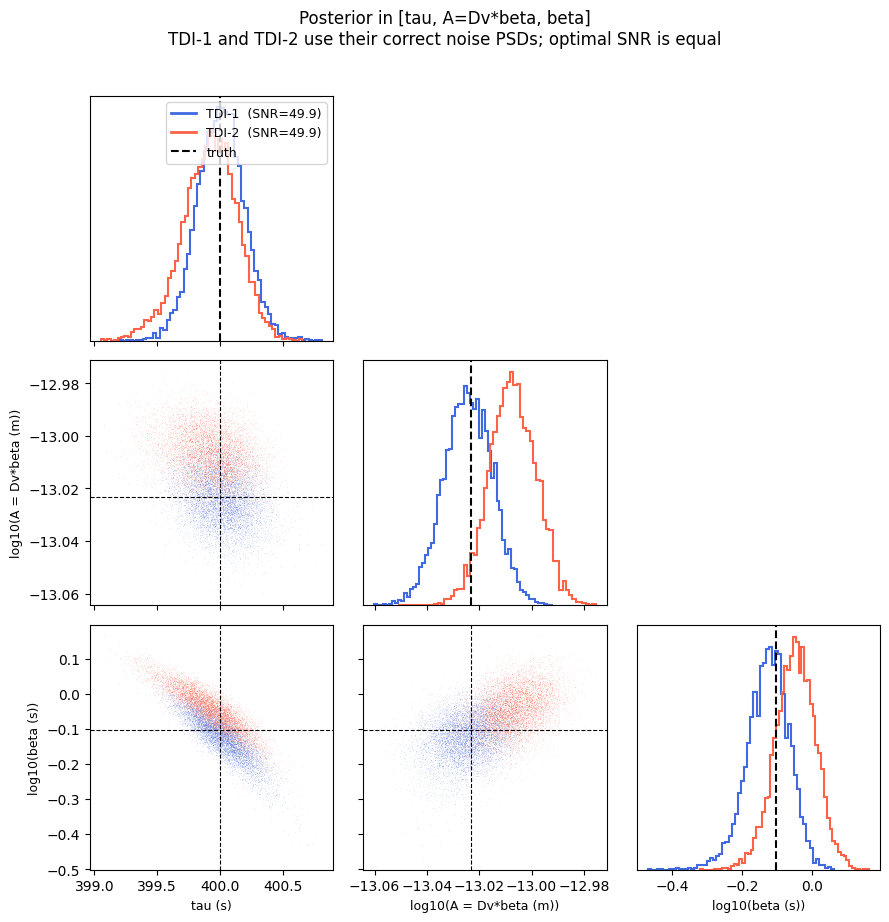

In [22]:
# Build sample arrays in [tau, A, beta] space for the corner plot
sp1 = np.column_stack([s1[:,0], a1, s1[:,2]])   # [tau, A, beta]
sp2 = np.column_stack([s2[:,0], a2, s2[:,2]])

plot_names  = ['tau (s)', 'A = Dv*beta (m)', 'beta (s)']
plot_truths = [TAU_TRUE, A_TRUE, BETA_TRUE]


def corner_plot(samples_list, labels, colors, param_names, truth, log_axes=None):
    n = samples_list[0].shape[1]
    log_axes = log_axes or set()
    fig, axes = plt.subplots(n, n, figsize=(3*n, 3*n))
    fig.subplots_adjust(hspace=0.05, wspace=0.05)

    def _v(s, i):  return np.log10(np.abs(s[:,i])) if i in log_axes else s[:,i]
    def _t(i):     return np.log10(abs(truth[i]))   if i in log_axes else truth[i]
    def _lbl(i):   return f'log10({param_names[i]})' if i in log_axes else param_names[i]

    for row in range(n):
        for col in range(n):
            ax = axes[row, col]
            if col > row:
                ax.set_visible(False); continue
            if col == row:
                for s, lbl, clr in zip(samples_list, labels, colors):
                    ax.hist(_v(s, col), bins=60, density=True,
                            histtype='step', color=clr, lw=1.5, label=lbl)
                ax.axvline(_t(col), color='k', lw=1.5, ls='--')
                ax.set_yticks([])
            else:
                for s, lbl, clr in zip(samples_list, labels, colors):
                    ax.plot(_v(s, col), _v(s, row), ',', color=clr, alpha=0.1, ms=1)
                ax.axvline(_t(col), color='k', lw=0.8, ls='--')
                ax.axhline(_t(row), color='k', lw=0.8, ls='--')
            if row == n-1:
                ax.set_xlabel(_lbl(col), fontsize=9)
            else:
                ax.set_xticklabels([])
            if col == 0 and row > 0:
                ax.set_ylabel(_lbl(row), fontsize=9)
            else:
                ax.set_yticklabels([])

    handles  = [plt.Line2D([0],[0], color=c, lw=2, label=l) for l,c in zip(labels,colors)]
    handles += [plt.Line2D([0],[0], color='k', lw=1.5, ls='--', label='truth')]
    axes[0,0].legend(handles=handles, fontsize=9, loc='upper right')
    return fig


fig = corner_plot(
    [sp1, sp2],
    [f'TDI-1  (SNR={snr1:.1f})', f'TDI-2  (SNR={snr2:.1f})'],
    ['royalblue', 'tomato'],
    plot_names, plot_truths, log_axes={1, 2})

fig.suptitle(
    'Posterior in [tau, A=Dv*beta, beta]\n'
    'TDI-1 and TDI-2 use their correct noise PSDs; optimal SNR is equal',
    y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


## 8. Whitened residual check

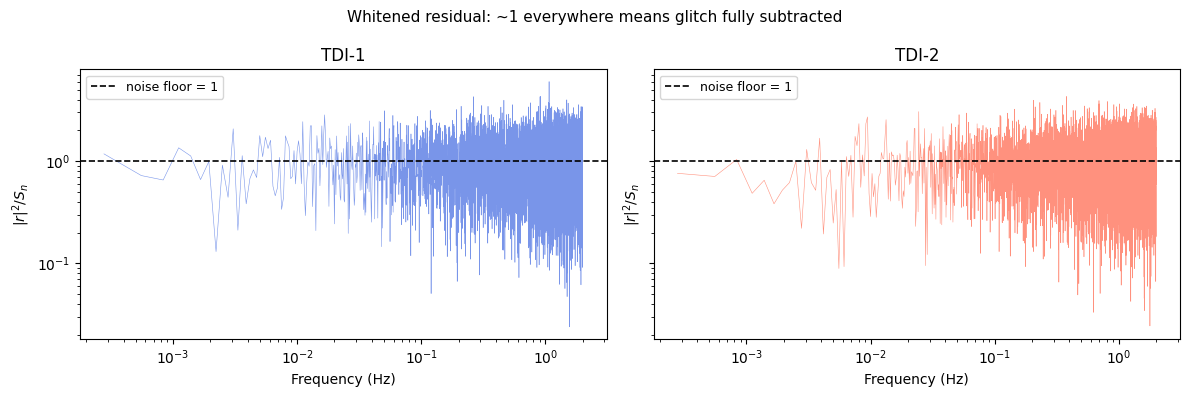

In [23]:
p_med1 = jnp.array(np.median(np.array(phys1), axis=0))
p_med2 = jnp.array(np.median(np.array(phys2), axis=0))

res1 = data1 - jg.clean_signal(p_med1, freq, T=T_ARM, tdi=1)
res2 = data2 - jg.clean_signal(p_med2, freq, T=T_ARM, tdi=2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, res, psd, title, clr in zip(
        axes, [res1, res2], [psd1, psd2],
        ['TDI-1', 'TDI-2'], ['royalblue', 'tomato']):
    wh = np.mean(np.abs(np.array(res[1:]))**2 / np.array(psd[1:]), axis=1)
    ax.loglog(np.array(freq[1:]), wh, color=clr, lw=0.4, alpha=0.7)
    ax.axhline(1.0, color='k', ls='--', lw=1.2, label='noise floor = 1')
    ax.set_xlabel('Frequency (Hz)');  ax.set_ylabel(r'$|r|^2/S_n$')
    ax.set_title(title);              ax.legend(fontsize=9)
plt.suptitle('Whitened residual: ~1 everywhere means glitch fully subtracted', fontsize=11)
plt.tight_layout()
plt.show()


## 9. Fisher information matrix

The Fisher matrix `Γ_ij = (∂h/∂θ_i | ∂h/∂θ_j)` gives the theoretical parameter uncertainties in the limit of large SNR.
Here computed via `jg.fisher_matrix` in physical `[τ, Δv, β]` space, then transformed to sampling coords `[τ, log A, log β]`.

Cross-check: Fisher 1σ should agree with the MCMC posterior widths when the posterior is close to Gaussian.


In [24]:
# Fisher in physical [tau, Deltav, beta] at the true parameters
Gamma1_phys = jg.fisher_matrix(params_true, freq, psd1, T=T_ARM, tdi=1)
Gamma2_phys = jg.fisher_matrix(params_true, freq, psd2, T=T_ARM, tdi=2)

# Transform to [tau, logA, logBeta] via the Jacobian
#   d(tau, Dv, beta) / d(tau, logA, logBeta):
#     dDv/d(logA)    = Dv,   dDv/d(logBeta)  = -Dv
#     dbeta/d(logBeta) = beta
tau_t, Dv_t, beta_t = float(params_true[0]), float(params_true[1]), float(params_true[2])
J_AB = jnp.array([[1.,  0.,    0.    ],
                   [0.,  Dv_t, -Dv_t  ],
                   [0.,  0.,   beta_t ]])   # J[phys_i, AB_j]

Gamma1_AB = J_AB.T @ Gamma1_phys @ J_AB
Gamma2_AB = J_AB.T @ Gamma2_phys @ J_AB
C1_fish = jnp.linalg.inv(Gamma1_AB)
C2_fish = jnp.linalg.inv(Gamma2_AB)
sF1 = jnp.sqrt(jnp.diag(C1_fish))
sF2 = jnp.sqrt(jnp.diag(C2_fish))

print('Fisher 1σ uncertainties in [tau (s), logA, logBeta]:')
print(f'  TDI-1:  sigma_tau={float(sF1[0]):.4f} s   sigma_logA={float(sF1[1]):.4f}   sigma_logBeta={float(sF1[2]):.4f}')
print(f'  TDI-2:  sigma_tau={float(sF2[0]):.4f} s   sigma_logA={float(sF2[1]):.4f}   sigma_logBeta={float(sF2[2]):.4f}')
print()

# Cross-check vs MCMC posterior widths
lA1_samp = np.array(chain1[:, 1])
lA2_samp = np.array(chain2[:, 1])
lB1_samp = np.array(chain1[:, 2])
lB2_samp = np.array(chain2[:, 2])
t1_samp  = np.array(chain1[:, 0])
t2_samp  = np.array(chain2[:, 0])

print(f'{"":12s}  {"σ_tau Fisher":>13s}  {"σ_tau MCMC":>11s}  {"σ_logA Fisher":>14s}  {"σ_logA MCMC":>12s}  {"σ_logβ Fisher":>14s}  {"σ_logβ MCMC":>12s}')
for lbl, sF, st, slA, slB in [
        ('TDI-1', sF1, t1_samp, lA1_samp, lB1_samp),
        ('TDI-2', sF2, t2_samp, lA2_samp, lB2_samp)]:
    print(f'{lbl:12s}  {float(sF[0]):13.4f}  {np.std(st):11.4f}  {float(sF[1]):14.4f}  {np.std(slA):12.4f}  {float(sF[2]):14.4f}  {np.std(slB):12.4f}')

print()
# Fisher correlation matrix in [tau, logA, logBeta] coords
print('Fisher correlation matrix TDI-1:')
D1 = np.diag(1.0 / np.array(sF1))
print(np.round(D1 @ np.array(C1_fish) @ D1, 3))
print('Fisher correlation matrix TDI-2:')
D2 = np.diag(1.0 / np.array(sF2))
print(np.round(D2 @ np.array(C2_fish) @ D2, 3))


Fisher 1σ uncertainties in [tau (s), logA, logBeta]:
  TDI-1:  sigma_tau=0.1939 s   sigma_logA=0.0210   sigma_logBeta=0.1433
  TDI-2:  sigma_tau=0.1939 s   sigma_logA=0.0210   sigma_logBeta=0.1433

               σ_tau Fisher   σ_tau MCMC   σ_logA Fisher   σ_logA MCMC   σ_logβ Fisher   σ_logβ MCMC
TDI-1                0.1939       0.1870          0.0210        0.0213          0.1433        0.1402
TDI-2                0.1939       0.2164          0.0210        0.0207          0.1433        0.1329

Fisher correlation matrix TDI-1:
[[ 1.    -0.256 -0.875]
 [-0.256  1.     0.293]
 [-0.875  0.293  1.   ]]
Fisher correlation matrix TDI-2:
[[ 1.    -0.256 -0.875]
 [-0.256  1.     0.293]
 [-0.875  0.293  1.   ]]


### 9.1 Covariance matrix comparison

Full `[τ, log A, log β]` covariance matrices from Fisher and MCMC.  
At SNR ~ 50 the posterior is nearly Gaussian, so they should agree at the 10–20% level on individual entries.


In [25]:
# MCMC sample covariance in [tau, logA, logBeta]
C1_mcmc = np.cov(np.array(chain1).T)
C2_mcmc = np.cov(np.array(chain2).T)

def fmt_cov(C, name):
    sig  = np.sqrt(np.diag(C))
    corr = C / np.outer(sig, sig)
    print(f'{name}')
    print(f'  σ: tau={sig[0]:.4f} s   logA={sig[1]:.5f}   logβ={sig[2]:.4f}')
    print('  Correlation:')
    for row in corr:
        print('   ', '  '.join(f'{v:+.3f}' for v in row))

print('=== Covariance comparison in [tau, logA, logBeta] ===\n')
for lbl_f, C_f, lbl_m, C_m in [
        ('Fisher TDI-1', C1_fish, 'MCMC   TDI-1', C1_mcmc),
        ('Fisher TDI-2', C2_fish, 'MCMC   TDI-2', C2_mcmc)]:
    fmt_cov(np.array(C_f), lbl_f)
    fmt_cov(C_m,           lbl_m)
    print()


=== Covariance comparison in [tau, logA, logBeta] ===

Fisher TDI-1
  σ: tau=0.1939 s   logA=0.02096   logβ=0.1433
  Correlation:
    +1.000  -0.256  -0.875
    -0.256  +1.000  +0.293
    -0.875  +0.293  +1.000
MCMC   TDI-1
  σ: tau=0.1870 s   logA=0.02131   logβ=0.1402
  Correlation:
    +1.000  -0.244  -0.858
    -0.244  +1.000  +0.279
    -0.858  +0.279  +1.000

Fisher TDI-2
  σ: tau=0.1939 s   logA=0.02096   logβ=0.1433
  Correlation:
    +1.000  -0.256  -0.875
    -0.256  +1.000  +0.293
    -0.875  +0.293  +1.000
MCMC   TDI-2
  σ: tau=0.2164 s   logA=0.02069   logβ=0.1329
  Correlation:
    +1.000  -0.289  -0.881
    -0.289  +1.000  +0.329
    -0.881  +0.329  +1.000



### 9.2 Fisher vs MCMC corner plots

Fisher Gaussian samples drawn from `MVN(MAP, C_Fisher)` in `[τ, log A, log β]` space, then converted to `[τ, A, β]`.  
Agreement between Fisher and MCMC contours confirms that the posterior is close to Gaussian at this SNR (~50).


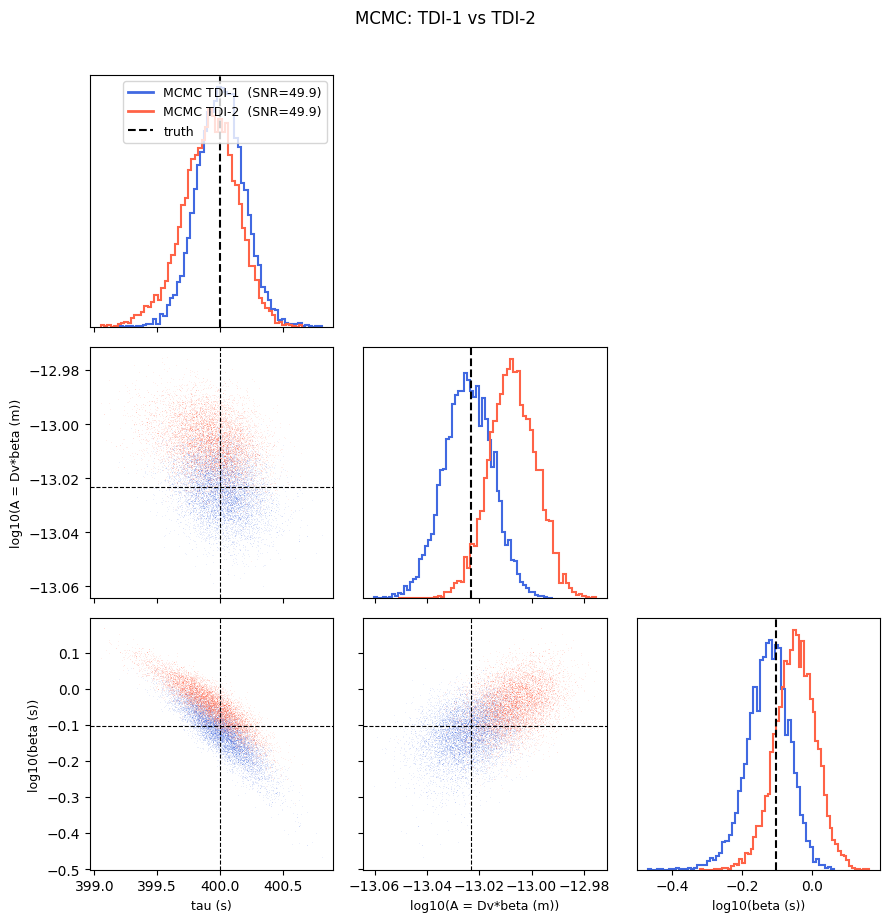

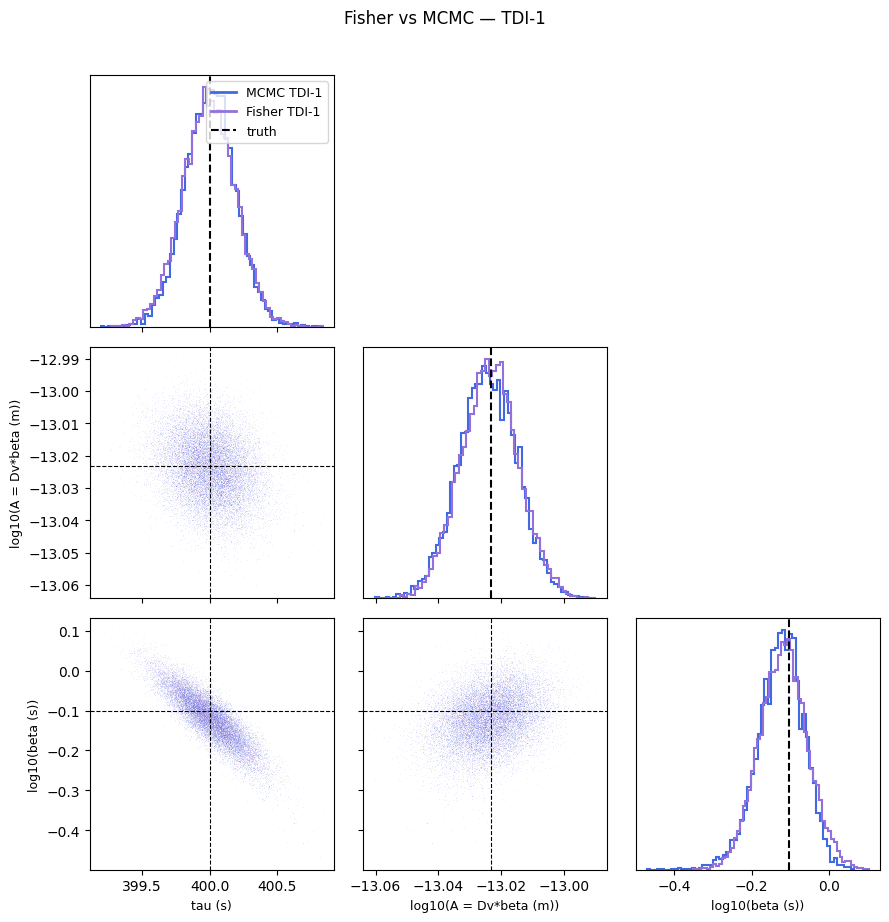

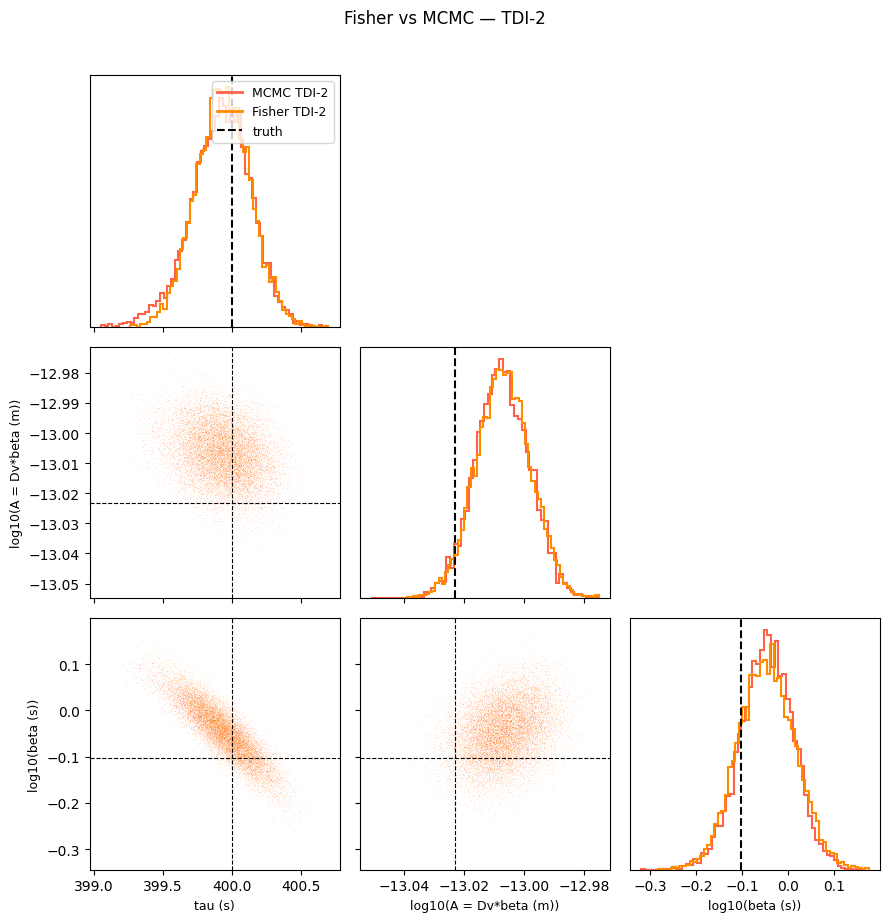

In [26]:
rng = np.random.default_rng(42)
N_FISH = len(chain1)

# Draw samples from Fisher Gaussian in [tau, logA, logBeta], centred at MAP
xi_fish1 = rng.multivariate_normal(np.array(xi_map1), np.array(C1_fish), N_FISH)
xi_fish2 = rng.multivariate_normal(np.array(xi_map2), np.array(C2_fish), N_FISH)

def to_plot_coords(xi_arr):
    """[tau, logA, logBeta] -> [tau, A, beta] for the corner plots."""
    return np.column_stack([xi_arr[:, 0],
                            np.exp(xi_arr[:, 1]),
                            np.exp(xi_arr[:, 2])])

sp_fish1 = to_plot_coords(xi_fish1)
sp_fish2 = to_plot_coords(xi_fish2)

THIN_F = THIN  # same thinning factor as MCMC chains
sp_fish1 = sp_fish1[::THIN_F]
sp_fish2 = sp_fish2[::THIN_F]

# ── Plot 1: MCMC TDI-1 vs MCMC TDI-2 (same as Section 7) ─────────────────
fig1 = corner_plot(
    [sp1, sp2],
    [f'MCMC TDI-1  (SNR={snr1:.1f})', f'MCMC TDI-2  (SNR={snr2:.1f})'],
    ['royalblue', 'tomato'],
    plot_names, plot_truths, log_axes={1, 2})
fig1.suptitle('MCMC: TDI-1 vs TDI-2', y=1.02, fontsize=12)
plt.tight_layout(); plt.show()

# ── Plot 2: MCMC TDI-1 vs Fisher TDI-1 ────────────────────────────────────
fig2 = corner_plot(
    [sp1, sp_fish1],
    ['MCMC TDI-1', 'Fisher TDI-1'],
    ['royalblue', 'mediumpurple'],
    plot_names, plot_truths, log_axes={1, 2})
fig2.suptitle('Fisher vs MCMC — TDI-1', y=1.02, fontsize=12)
plt.tight_layout(); plt.show()

# ── Plot 3: MCMC TDI-2 vs Fisher TDI-2 ────────────────────────────────────
fig3 = corner_plot(
    [sp2, sp_fish2],
    ['MCMC TDI-2', 'Fisher TDI-2'],
    ['tomato', 'darkorange'],
    plot_names, plot_truths, log_axes={1, 2})
fig3.suptitle('Fisher vs MCMC — TDI-2', y=1.02, fontsize=12)
plt.tight_layout(); plt.show()
